# Survey Overview (Sharing-Eligible Responses)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("./../mid-term-survey.csv")
print(f"Loaded {len(df)} responses with {df.shape[1]} columns.")


Loaded 95 responses with 20 columns.


In [2]:
df.head()

,Timestamp,I have reviewed my Milestone 2 feedback.,Which feedback structure do you prefer overall for milestones?,"Compared with Milestone 1 feedback, Milestone 2 feedback was:","Did you expect a different type of early feedback for this milestone? If yes, what did you expect?",The early feedback helped me identify specific mistakes.,The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.,This process helps me meet the deliverable expectations.,I am comfortable with AI-assisted early feedback if it is human-reviewed.,I trust the challenge/appeal path when feedback seems wrong.,I clearly understood what role AI vs TAs/instructor played.,I am confident in TA final regrading fairness and consistency.,How did the submit + quick detailed feedback + resubmission cycle affect your learning process?,In what assignment scenarios would you NOT want this model (early feedback + resubmission)?,Biggest advantage for you of bringing GenAI into early feedback:,Biggest disadvantage for you of bringing GenAI into early feedback:,One concrete change you recommend for the next milestone feedback process:,What else would you like to share with the instructor and TAs on this topic?,Consent 2,Consent 3
0,2/14/2026 16:04:44,Yes,Early feedback + resubmission,About the same,No,3 - Neutral,4 - Agree,4 - Agree,3 - Neutral,3 - Neutral,4 - Agree,4 - Agree,resubmission clarify what i was right and what...,already well-understanding.,In good logic and effective,not that trustful,no,we need resubmission,I consent to my name being attached to my resp...,I’m open to a follow-up conversation; please c...
1,2/14/2026 17:20:50,Yes,Early feedback + resubmission,About the same,NaN,4 - Agree,5 - Strongly agree,5 - Strongly agree,4 - Agree,3 - Neutral,4 - Agree,4 - Agree,I think it actually helped me learn a lot beca...,I can't think of anytime I wouldn't.,It finds details that humans might not even no...,Sometimes the AI is almost looking for somethi...,Just making the feedback comment a bit more re...,NaN,NaN,NaN
2,2/14/2026 17:41:50,Yes,Hybrid/other approach,More useful,Maybe comment on the pdf so it might be more c...,4 - Agree,3 - Neutral,4 - Agree,4 - Agree,4 - Agree,3 - Neutral,4 - Agree,The submit + quick feedback + resubmission cyc...,If the workload is heavy and the assignment an...,The biggest advantage is getting fast feedback...,It might could feel overwhelming if there are ...,"Maybe make the AI feedback a bit more focused,...",NaN,I consent to my name being attached to my resp...,I’m open to a follow-up conversation; please c...
3,2/15/2026 15:35:05,Yes,Early feedback + resubmission,More useful,NaN,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,3 - Neutral,4 - Agree,4 - Agree,5 - Strongly agree,The submit + quick feedback + resubmission cyc...,During the test?,The biggest advantage for me is getting immedi...,One possible disadvantage is that it can make ...,I would recommend is providing a short summary...,NaN,I consent to my name being attached to my resp...,NaN
4,2/16/2026 12:20:02,Yes,Early feedback + resubmission,About the same,NaN,4 - Agree,4 - Agree,4 - Agree,2 - Disagree,4 - Agree,3 - Neutral,3 - Neutral,"Through the submit, quick detailed feedback, a...",I would not want the model of early feedback a...,"Perhaps speed of grading, as GenAI may be able...","Potential for error, specifically through pote...",Being more specific when pointing out areas wh...,NaN,NaN,NaN


In [3]:
# Locate consent column and build consent flags
consent_opts = {
    "consent": "Timestamp",
    "named_use": "Consent 2",
    "follow_up": "Consent 3"
}

for k, col_name in consent_opts.items():
    df[k] = ~df[col_name].isna()

df_share = df.copy()
print(f"Responses agreeing to share beyond class: {len(df_share)} / {len(df)}")
print("Consent option counts (all responses):")
print(df[["consent", "named_use", "follow_up"]].sum().sort_values(ascending=False))

Responses agreeing to share beyond class: 95 / 95
Consent option counts (all responses):
consent      95
follow_up    24
named_use    22
dtype: int64


In [4]:
# Plot 1: Consent option uptake across all respondents
consent_counts = df[["consent", "named_use", "follow_up"]].sum().sort_values(ascending=False)
labels = {
    "consent": "Consent",
    "named_use": "Named attribution",
    "follow_up": "Open to follow-up"
}


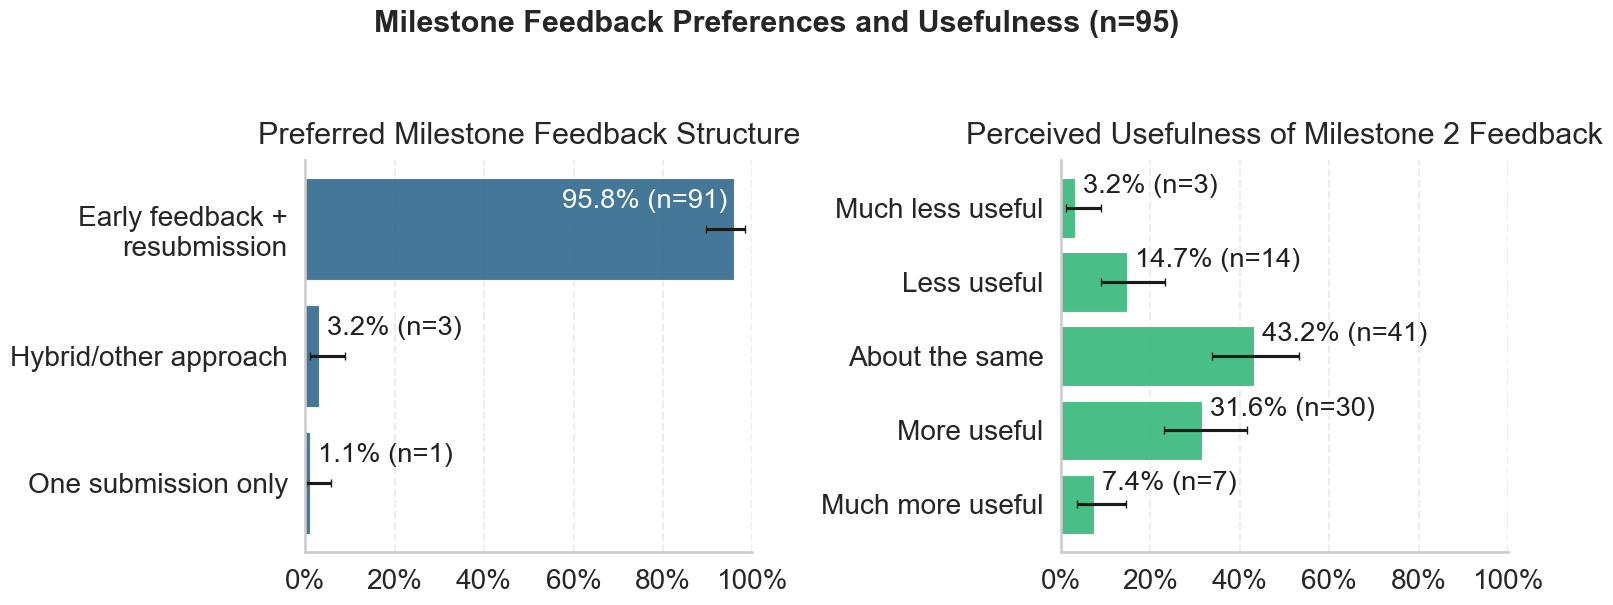

In [5]:
# Plot 2: Distribution of milestone preference and perceived usefulness (sharing-eligible only)
from textwrap import fill
from matplotlib.ticker import PercentFormatter

pref_col = "Which feedback structure do you prefer overall for milestones?"
useful_col = "Compared with Milestone 1 feedback, Milestone 2 feedback was:"


def _size(value, fallback):
    return float(value) if isinstance(value, (int, float)) else float(fallback)


def wilson_interval(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + (z ** 2) / n
    center = (p + (z ** 2) / (2 * n)) / denom
    margin = (z * np.sqrt((p * (1 - p) / n) + (z ** 2) / (4 * n ** 2))) / denom
    return max(0.0, center - margin), min(1.0, center + margin)


def summarize_proportions(series, order=None):
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    else:
        counts = counts.sort_values(ascending=False)

    n = int(counts.sum())
    rows = []
    for category, k in counts.items():
        lo, hi = wilson_interval(int(k), n)
        rows.append({
            "category": str(category),
            "count": int(k),
            "prop": k / n if n else 0.0,
            "ci_low": lo,
            "ci_high": hi,
            "n_total": n,
        })
    return pd.DataFrame(rows)


left_df = summarize_proportions(df_share[pref_col])
left_df["category"] = left_df["category"].map(lambda x: fill(x, width=26))
left_df = left_df.iloc[::-1]

usefulness_order = [
    "Much less useful",
    "Less useful",
    "About the same",
    "More useful",
    "Much more useful",
]
right_df = summarize_proportions(df_share[useful_col], order=usefulness_order)
right_df["category"] = right_df["category"].map(lambda x: fill(x, width=20))
right_df = right_df.iloc[::-1]

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    subplot_title_size = _size(plt.rcParams.get("axes.titlesize", 14), 14)
    axis_label_size = _size(plt.rcParams.get("axes.labelsize", 12), 12)
    tick_label_size = _size(plt.rcParams.get("xtick.labelsize", 11), 11)
    annotation_fontsize = axis_label_size * 0.9

    for ax, frame, title, color in [
        (axes[0], left_df, "Preferred Milestone Feedback Structure", "#31688E"),
        (axes[1], right_df, "Perceived Usefulness of Milestone 2 Feedback", "#35B779"),
    ]:
        xerr = np.vstack([
            frame["prop"] - frame["ci_low"],
            frame["ci_high"] - frame["prop"],
        ])

        ax.barh(
            frame["category"],
            frame["prop"],
            xerr=xerr,
            color=color,
            alpha=0.9,
            capsize=3,
            edgecolor="white",
            linewidth=0.8,
        )
        ax.set_title(title, pad=12, fontsize=subplot_title_size)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.set_xlim(0, 1.0)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.grid(axis="y", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", labelsize=tick_label_size)
        ax.tick_params(axis="y", labelsize=tick_label_size)

        for y, (_, row) in enumerate(frame.iterrows()):
            high_share = row["prop"] >= 0.95
            if high_share:
                # Keep very-high-share labels inside the bar for readability.
                x_pos = max(row["prop"] - 0.015, 0.05)
                ha = "right"
                text_color = "white"
            else:
                x_pos = min(row["prop"] + 0.018, 0.985)
                ha = "left" if row["prop"] < 0.9 else "right"
                text_color = "#1f1f1f"

            y_pos = y + 0.13  # nudge labels slightly downward for cleaner alignment
            ax.text(
                x_pos,
                y_pos,
                f"{row['prop']:.1%} (n={row['count']})",
                va="bottom",
                ha=ha,
                fontsize=annotation_fontsize,
                color=text_color,
            )

    fig.suptitle(
        f"Milestone Feedback Preferences and Usefulness (n={len(df_share)})",
        y=1.03,
        fontsize=subplot_title_size,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


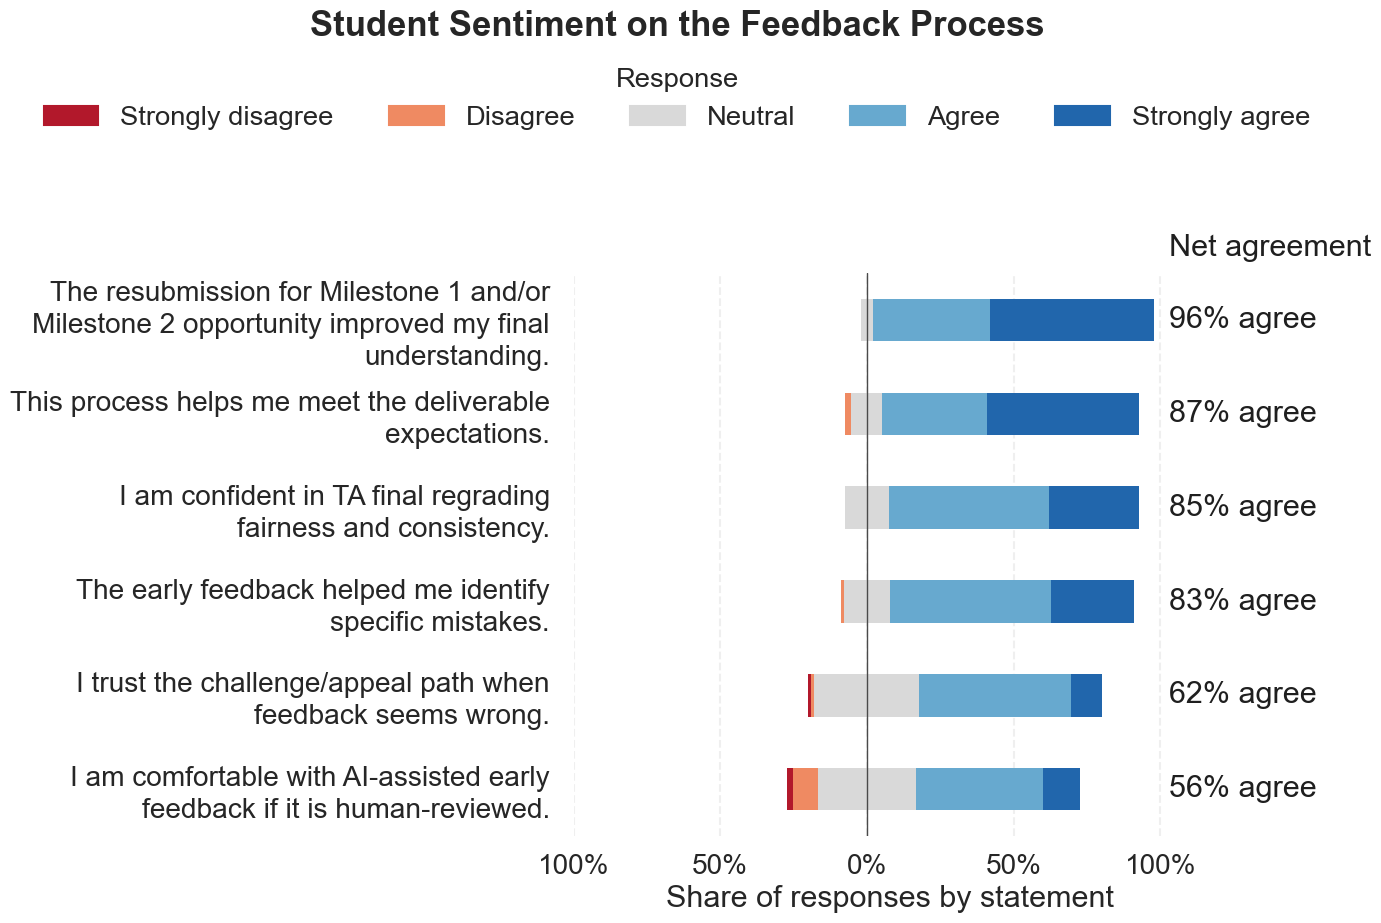

In [6]:
# Plot 3: Diverging Likert distributions for key process-confidence statements (sharing-eligible only)
from textwrap import fill
from matplotlib.ticker import FuncFormatter

likert_cols = [
    "The early feedback helped me identify specific mistakes.",
    "The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.",
    "This process helps me meet the deliverable expectations.",
    "I am comfortable with AI-assisted early feedback if it is human-reviewed.",
    "I trust the challenge/appeal path when feedback seems wrong.",
    "I am confident in TA final regrading fairness and consistency.",
]

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree",
]

short_order = [label.split(" - ", 1)[1] for label in likert_order]
color_map = {
    "1 - Strongly disagree": "#B2182B",
    "2 - Disagree": "#EF8A62",
    "3 - Neutral": "#D9D9D9",
    "4 - Agree": "#67A9CF",
    "5 - Strongly agree": "#2166AC",
}

# Response distribution by question
rows = []
for col in likert_cols:
    row = df_share[col].value_counts(normalize=True).reindex(likert_order).fillna(0)
    rows.append(row)

dist_df = pd.DataFrame(rows, index=likert_cols)

# Order statements by overall agreement to improve scanability
agree_share = dist_df["4 - Agree"] + dist_df["5 - Strongly agree"]
dist_df = dist_df.loc[agree_share.sort_values(ascending=False).index]

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 9.6))
    y_step = 1.32
    y_pos = np.arange(len(dist_df)) * y_step

    axis_label_size = plt.rcParams.get("axes.labelsize", 14)
    if isinstance(axis_label_size, str):
        axis_label_size = 14
    tick_label_size = plt.rcParams.get("xtick.labelsize", 12)
    if isinstance(tick_label_size, str):
        tick_label_size = 12

    for i, (_, row) in enumerate(dist_df.iterrows()):
        y = y_pos[i]
        sd = row["1 - Strongly disagree"]
        d = row["2 - Disagree"]
        n = row["3 - Neutral"]
        a = row["4 - Agree"]
        sa = row["5 - Strongly agree"]

        starts = {
            "1 - Strongly disagree": -(sd + d + n / 2),
            "2 - Disagree": -(d + n / 2),
            "3 - Neutral": -(n / 2),
            "4 - Agree": n / 2,
            "5 - Strongly agree": n / 2 + a,
        }

        for label in likert_order:
            ax.barh(
                y,
                row[label],
                left=starts[label],
                color=color_map[label],
                edgecolor="none",
                linewidth=0,
                height=0.60,
            )

        ax.text(
            1.03,
            y,
            f"{(a + sa):.0%} agree",
            va="center",
            ha="left",
            fontsize=axis_label_size,
            color="#1f1f1f",
        )

    ax.axvline(0, color="#4a4a4a", linewidth=1)
    ax.set_xlim(-1.0, 1.16)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.0%}"))
    ax.set_yticks(y_pos)
    ax.set_yticklabels([fill(q, width=42) for q in dist_df.index], linespacing=1.30)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.patch.set_edgecolor("none")
    ax.patch.set_linewidth(0)
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size, pad=8)

    fig.suptitle("Student Sentiment on the Feedback Process", y=0.975, fontsize=axis_label_size + 3, fontweight="bold")
    ax.set_xlabel("Share of responses by statement", fontsize=axis_label_size)
    ax.set_ylabel("", fontsize=axis_label_size)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map[label])
        for label in likert_order
    ]
    ax.text(1.03, -0.9, "Net agreement", fontsize=axis_label_size, fontweight="normal", color="#1f1f1f")

    fig.legend(
        legend_handles,
        short_order,
        title="Response",
        ncol=5,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        fontsize=axis_label_size * 0.9,
        title_fontsize=axis_label_size * 0.9,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.85])
    plt.show()


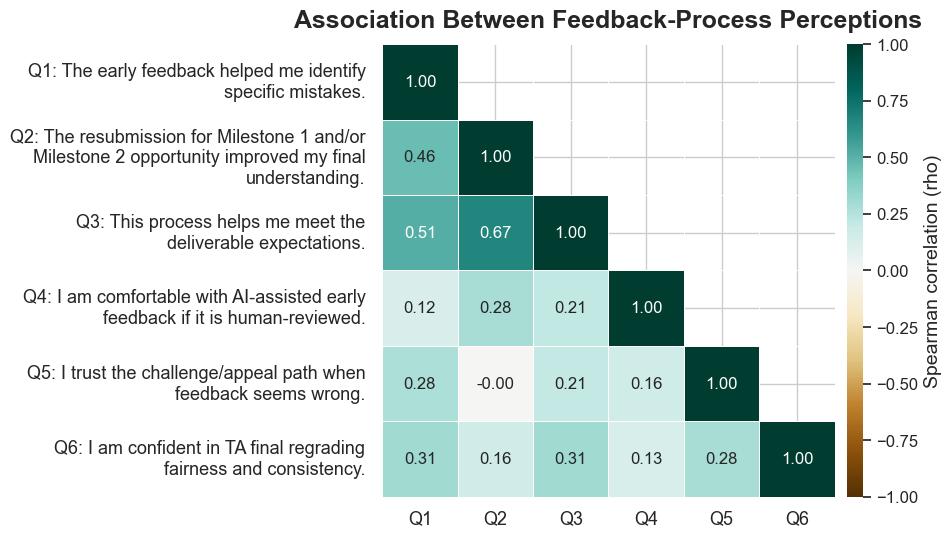

Question key:
Q1: The early feedback helped me identify specific mistakes.
Q2: The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final
understanding.
Q3: This process helps me meet the deliverable expectations.
Q4: I am comfortable with AI-assisted early feedback if it is human-reviewed.
Q5: I trust the challenge/appeal path when feedback seems wrong.
Q6: I am confident in TA final regrading fairness and consistency.


In [7]:
# Plot 4: Correlation heatmap among Likert items (sharing-eligible only)
# Ordinal Likert responses are summarized with Spearman correlations.

from textwrap import fill
from mpl_toolkits.axes_grid1 import make_axes_locatable

likert_num = df_share[likert_cols].apply(
    lambda s: pd.to_numeric(s.str.extract(r"^(\d)")[0], errors="coerce")
)
corr = likert_num.corr(method="spearman")

q_codes = [f"Q{i+1}" for i in range(len(likert_cols))]
y_labels = [fill(f"{code}: {q}", width=44) for code, q in zip(q_codes, likert_cols)]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Softer diverging scale: negative=brown, positive=green.
corr_cmap = sns.color_palette("BrBG", as_cmap=True)

fig, ax = plt.subplots(figsize=(9.2, 8.2))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3.5%", pad=0.12)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=corr_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    linecolor="white",
    xticklabels=q_codes,
    yticklabels=y_labels,
    annot_kws={"fontsize": 12},
    cbar_ax=cax,
    cbar_kws={"label": "Spearman correlation (rho)"},
    ax=ax,
)

ax.set_title("Association Between Feedback-Process Perceptions", pad=12, fontsize=18, fontweight="bold")
ax.tick_params(axis="x", rotation=0, labelsize=13)
ax.tick_params(axis="y", rotation=0, pad=6, labelsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spearman correlation (rho)", size=14)

plt.tight_layout()
plt.show()

print("Question key:")
for code, question in zip(q_codes, likert_cols):
    print(f"{code}: {fill(question, width=95)}")


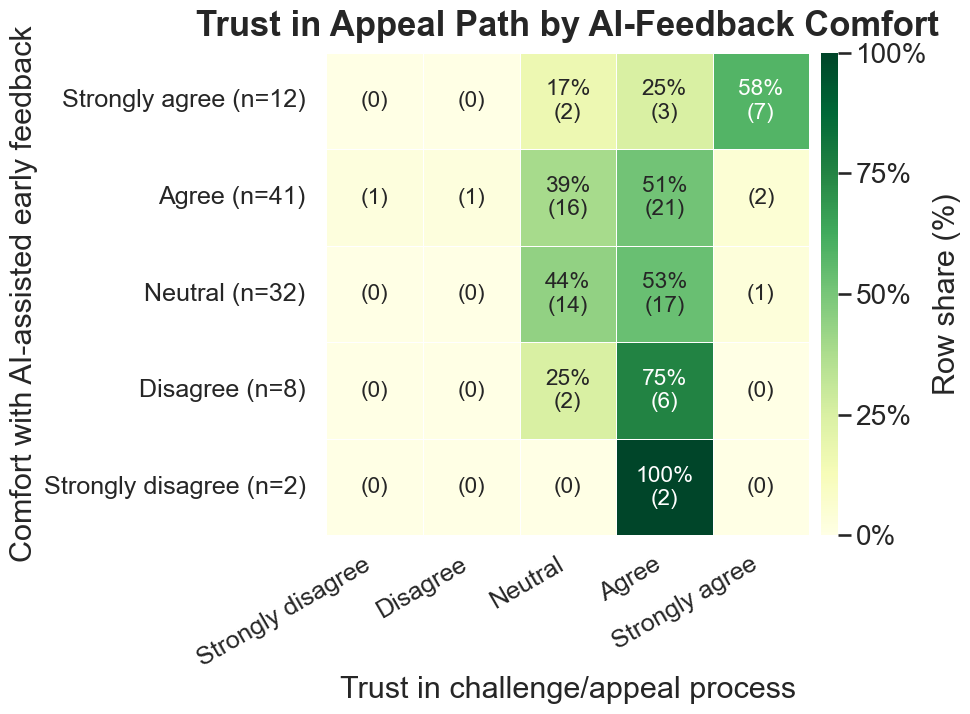

In [8]:
# Plot 5: Relationship between AI comfort and trust in challenge/appeal path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import PercentFormatter

ai_col = "I am comfortable with AI-assisted early feedback if it is human-reviewed."
trust_col = "I trust the challenge/appeal path when feedback seems wrong."

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree",
]
short_labels = [label.split(" - ", 1)[1] for label in likert_order]
row_order = likert_order[::-1]  # show Strongly agree at top
row_short_labels = [label.split(" - ", 1)[1] for label in row_order]

ct_counts = pd.crosstab(df_share[ai_col], df_share[trust_col])
ct_counts = ct_counts.reindex(index=row_order, columns=likert_order, fill_value=0)
ct_row = ct_counts.div(ct_counts.sum(axis=1), axis=0).fillna(0)

row_totals = ct_counts.sum(axis=1).reindex(row_order)
y_labels = [f"{lbl} (n={int(row_totals.iloc[i])})" for i, lbl in enumerate(row_short_labels)]

annot = ct_row.copy().astype(str)
for i in range(ct_row.shape[0]):
    for j in range(ct_row.shape[1]):
        p_cell = ct_row.iat[i, j]
        n_cell = ct_counts.iat[i, j]
        if p_cell < 0.05:
            annot.iat[i, j] = f"({n_cell})"
        else:
            annot.iat[i, j] = f"{p_cell:.0%}\n({n_cell})"

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(10.0, 7.6))

    axis_label_size = plt.rcParams.get("axes.labelsize", 14)
    if isinstance(axis_label_size, str):
        axis_label_size = 14
    tick_label_size = plt.rcParams.get("xtick.labelsize", 12)
    if isinstance(tick_label_size, str):
        tick_label_size = 12
    tick_label_small = tick_label_size * 0.90

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.12)

    sns.heatmap(
        ct_row,
        annot=annot,
        fmt="",
        cmap="YlGn",
        vmin=0,
        vmax=1,
        linewidths=0.6,
        linecolor="white",
        square=True,
        xticklabels=short_labels,
        yticklabels=y_labels,
        annot_kws={"fontsize": tick_label_small * 0.90},
        cbar_ax=cax,
        cbar_kws={"label": "Row share (%)", "ticks": [0, 0.25, 0.5, 0.75, 1.0]},
        ax=ax,
    )

    ax.set_title("Trust in Appeal Path by AI-Feedback Comfort", pad=12, fontsize=axis_label_size + 3, fontweight="bold")
    ax.set_xlabel("Trust in challenge/appeal process", fontsize=axis_label_size)
    ax.set_ylabel("Comfort with AI-assisted early feedback", fontsize=axis_label_size)
    ax.tick_params(axis="x", rotation=30, labelsize=tick_label_small)
    ax.tick_params(axis="y", rotation=0, labelsize=tick_label_small, pad=6)
    plt.setp(ax.get_xticklabels(), ha="right")

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=tick_label_size)
    cbar.set_label("Row share (%)", size=axis_label_size)
    cbar.formatter = PercentFormatter(xmax=1, decimals=0)
    cbar.update_ticks()

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


In [9]:
# Quick numeric summary for interpretation
print("Sharing-eligible sample size:", len(df_share))
print("Top preferred structure:")
print(df_share[pref_col].value_counts().head(3))

print("Average Likert scores (1-5):")
mean_scores = likert_num.mean().sort_values(ascending=False)
for k, v in mean_scores.items():
    print(f"- {k}: {v:.2f}")

Sharing-eligible sample size: 95
Top preferred structure:
Which feedback structure do you prefer overall for milestones?
Early feedback + resubmission    91
Hybrid/other approach             3
One submission only               1
Name: count, dtype: int64
Average Likert scores (1-5):
- The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.: 4.52
- This process helps me meet the deliverable expectations.: 4.37
- I am confident in TA final regrading fairness and consistency.: 4.16
- The early feedback helped me identify specific mistakes.: 4.11
- I trust the challenge/appeal path when feedback seems wrong.: 3.69
- I am comfortable with AI-assisted early feedback if it is human-reviewed.: 3.56


In [10]:
# If needed:
# !pip install -q sentence-transformers scikit-learn plotly

import numpy as np
import pandas as pd
import plotly.express as px
from textwrap import fill
from html import escape
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import warnings
import re
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)


# ---------- 1) Confirm consent-eligible base from current COUHES dataframe ----------
print(f"Share-beyond-class responses: {len(df_share)} / {len(df)}")


# ---------- 2) Open-ended columns ----------
open_ended_cols = [
    "How did the submit + quick detailed feedback + resubmission cycle affect your learning process?",
    "In what assignment scenarios would you NOT want this model (early feedback + resubmission)?",
    "Biggest advantage for you of bringing GenAI into early feedback:",
    "Biggest disadvantage for you of bringing GenAI into early feedback:",
    # "One concrete change you recommend for the next milestone feedback process:",
    "What else would you like to share with the instructor and TAs on this topic?"
]

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")


def analyze_open_ended(question_col, min_chars=12):
    s = df_share[question_col].dropna().astype(str).str.strip()
    s = s[s.str.len() >= min_chars]
    docs = s.tolist()
    docs = pd.Series(docs).dropna().astype(str).str.strip()
    docs = docs[docs.str.len() >= 5].drop_duplicates().tolist()


    print("\n" + "=" * 90)
    print(question_col)
    print(f"Usable responses: {len(docs)}")

    if len(docs) < 8:
        print("Too few responses for stable clustering/visualization. Skipping.")
        return

    # Embeddings
    emb = sentence_model.encode(
        docs,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)
    emb = np.ascontiguousarray(emb, dtype=np.float32)
    emb = np.nan_to_num(emb, nan=0.0, posinf=1.0, neginf=-1.0)
    perplexity = max(2, min(8, len(emb) - 1))

    # Agglomerative clusters
    n_clusters = min(6, max(2, int(np.sqrt(len(docs) / 2))))
    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward").fit_predict(emb)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity,
        init="random",
        learning_rate="auto",
        metric="euclidean",
        method="exact",
        max_iter=2000
    )
    xy = tsne.fit_transform(emb)

    plot_df = pd.DataFrame({
        "x": xy[:, 0],
        "y": xy[:, 1],
        "cluster": labels.astype(str),
        "doc_num": [f"Resp {i+1}" for i in range(len(docs))],
        "document": docs,
        "wrapped_doc": [fill(d, width=60).replace("\n", "<br>") for d in docs]
    }).sort_values("cluster")

    fig = px.scatter(
        plot_df,
        x="x",
        y="y",
        color="cluster",
        custom_data=["doc_num", "wrapped_doc", "cluster"],
        # title=f"t-SNE + Agglomerative: {question_col}",
        title=f"<b>{question_col}</b>",
        labels={"cluster": "Cluster"},
        category_orders={"cluster": [str(i) for i in range(n_clusters)]}
    )

    fig.update_traces(
        marker=dict(size=11, line=dict(width=1, color="white")),
        hovertemplate="<b>%{customdata[0]}</b><br>"
                      "Cluster: %{customdata[2]}<br><br>"
                      "%{customdata[1]}<br>"
                      "<extra></extra>"
    )
    fig.update_layout(width=900, height=550, hoverlabel=dict(align="left"))
    fig.show()

    # Cluster size summary
    size_df = (
        pd.Series(labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )
    size_df["pct"] = (size_df["count"] / size_df["count"].sum() * 100).round(1)
    display(size_df)

    # Cluster-unique clause mining (contrastive semantic scoring)
    # We extract sub-sentences and score each clause by how much closer it is to its
    # own cluster than to other clusters.
    clause_records = []
    split_pattern = re.compile(r"(?<=[.!?;:])\s+|\n+")

    for doc_i, text in enumerate(docs):
        parts = [p.strip(" -\t") for p in split_pattern.split(text)]
        for part in parts:
            if len(part) < 20:
                continue
            norm = re.sub(r"\s+", " ", part.lower()).strip()
            clause_records.append({
                "cluster": int(labels[doc_i]),
                "doc_idx": doc_i,
                "clause": part,
                "norm": norm,
            })

    clause_df = pd.DataFrame(clause_records)

    # Build cluster centroids from response embeddings (already normalized embeddings).
    cluster_ids = sorted(set(int(c) for c in labels))
    centroid_map = {}
    for c in cluster_ids:
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        v = emb[idx].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        centroid_map[c] = v

    cluster_top_unique_clauses = {c: [] for c in range(n_clusters)}
    ranking_rows = []

    if not clause_df.empty and centroid_map:
        clause_texts = clause_df["clause"].tolist()
        clause_emb = sentence_model.encode(
            clause_texts,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float64)
        clause_emb = np.ascontiguousarray(np.nan_to_num(clause_emb, nan=0.0, posinf=1.0, neginf=-1.0))

        centroid_ids = sorted(centroid_map.keys())
        centroid_mat = np.vstack([centroid_map[c] for c in centroid_ids]).astype(np.float64)
        centroid_mat = np.ascontiguousarray(np.nan_to_num(centroid_mat, nan=0.0, posinf=1.0, neginf=-1.0))

        # Stable cosine similarity without direct matrix-multiplication on this environment.
        clause_norm = np.linalg.norm(clause_emb, axis=1, keepdims=True)
        centroid_norm = np.linalg.norm(centroid_mat, axis=1, keepdims=True)
        clause_norm[~np.isfinite(clause_norm) | (clause_norm == 0)] = 1.0
        centroid_norm[~np.isfinite(centroid_norm) | (centroid_norm == 0)] = 1.0
        clause_emb = clause_emb / clause_norm
        centroid_mat = centroid_mat / centroid_norm

        sim_cols = [np.sum(clause_emb * centroid_mat[j], axis=1) for j in range(centroid_mat.shape[0])]
        sim_mat = np.column_stack(sim_cols).astype(np.float32)
        sim_mat = np.nan_to_num(sim_mat, nan=0.0, posinf=1.0, neginf=-1.0)

        centroid_col = {c: i for i, c in enumerate(centroid_ids)}

        own_col = clause_df["cluster"].map(centroid_col).to_numpy()
        own_sim = sim_mat[np.arange(len(clause_df)), own_col]

        max_other = np.empty(len(clause_df), dtype=np.float32)
        for i in range(len(clause_df)):
            row = sim_mat[i]
            j = own_col[i]
            if row.shape[0] <= 1:
                max_other[i] = -1.0
            else:
                max_other[i] = np.max(np.delete(row, j))

        clause_df["own_sim"] = own_sim
        clause_df["contrast"] = own_sim - max_other

        # Aggregate near-duplicate clauses inside each cluster.
        agg = (
            clause_df.groupby(["cluster", "norm"], as_index=False)
            .agg(
                clause=("clause", "first"),
                support=("doc_idx", "nunique"),
                mean_contrast=("contrast", "mean"),
                mean_own_sim=("own_sim", "mean"),
            )
        )
        agg["score"] = agg["mean_contrast"] + 0.04 * agg["support"]

        for c in range(n_clusters):
            idx = np.where(labels == c)[0]
            if len(idx) == 0:
                continue

            sub = agg[agg["cluster"] == c].copy()
            # Prefer phrases that appear in multiple responses; fallback if needed.
            sub2 = sub[sub["support"] >= 2].copy()
            if sub2.empty:
                sub2 = sub

            sub2 = sub2.sort_values(
                ["score", "mean_contrast", "support", "mean_own_sim"],
                ascending=False,
            )

            top_clauses = sub2["clause"].head(6).tolist()
            cluster_top_unique_clauses[c] = top_clauses

            for rank, clause in enumerate(top_clauses, start=1):
                ranking_rows.append({
                    "cluster": c,
                    "ranking": rank,
                    "top_unique_clause": clause,
                })

    ranking_df = pd.DataFrame(
        ranking_rows,
        columns=["cluster", "ranking", "top_unique_clause"],
    ).sort_values(["cluster", "ranking"])
    palette_rank = ["#E8F1FB", "#EAF7EA", "#FFF4E5", "#FDEBEC", "#EEF2FF", "#F2F2F2"]
    cluster_to_color_rank = {c: palette_rank[int(c) % len(palette_rank)] for c in sorted(ranking_df["cluster"].unique())}

    def color_rank_row(row):
        color = cluster_to_color_rank.get(row["cluster"], "#FFFFFF")
        return [f"background-color: {color}"] * len(row)

    display(
        ranking_df.style
        .apply(color_rank_row, axis=1)
        .set_properties(
            subset=["top_unique_clause"],
            **{
                "min-width": "200px",
                "max-width": "500px",
                "white-space": "normal",
                "text-align": "left",
            }
        )
    )

    # Representative responses (closest to each cluster mean embedding)
    rep_rows = []
    for c in range(n_clusters):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue

        # Compute a pseudo-centroid for this cluster and rank by cosine similarity.
        cluster_emb = emb[idx]
        centroid = cluster_emb.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_emb, centroid).ravel()
        top_local = np.argsort(sims)[::-1][:3]  # top 3 per cluster

        for rank, local_i in enumerate(top_local, start=1):
            global_i = idx[local_i]
            rep_rows.append({
                "cluster": c,
                "rank_in_cluster": rank,
                "response": docs[global_i]
            })

    rep_df = pd.DataFrame(rep_rows).sort_values(["cluster", "rank_in_cluster"]).copy()
    # rep_df["top_unique_clauses"] = rep_df["cluster"].map(lambda c: " || ".join(cluster_top_unique_clauses.get(c, [])[:4]))

    def bold_terms_in_text(text, terms):
        safe = escape(str(text))
        # Match longer phrases first to avoid partial overlaps.
        ordered_terms = sorted({t for t in terms if t}, key=len, reverse=True)
        for term in ordered_terms:
            safe_term = escape(term)
            pattern = re.compile(rf"(?i)({re.escape(safe_term)})")
            safe = pattern.sub(r"<b>\1</b>", safe)
        return safe

    rep_df["response"] = rep_df.apply(
        lambda r: bold_terms_in_text(r["response"], cluster_top_unique_clauses.get(r["cluster"], [])),
        axis=1,
    )

    # Color rows by cluster for quicker scanning.
    palette = ["#E8F1FB", "#EAF7EA", "#FFF4E5", "#FDEBEC", "#EEF2FF", "#F2F2F2"]
    cluster_to_color = {c: palette[int(c) % len(palette)] for c in sorted(rep_df["cluster"].unique())}

    def color_row(row):
        color = cluster_to_color.get(row["cluster"], "#FFFFFF")
        return [f"background-color: {color}"] * len(row)

    display(
        rep_df.style
        .apply(color_row, axis=1)
        .format({"response": lambda x: x}, escape=None)
        .set_properties(
            subset=["response"],
            **{"white-space": "normal", "text-align": "left", "max-width": "900px"}
        )
    )


# ---------- 3) Run all open-ended questions ----------
for col in open_ended_cols:
    analyze_open_ended(col)


/Users/belencsf/.pyenv/versions/3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Share-beyond-class responses: 95 / 95

How did the submit + quick detailed feedback + resubmission cycle affect your learning process?
Usable responses: 95


,cluster,count,pct
0,0,26,27.4
1,1,15,15.8
2,2,8,8.4
3,3,23,24.2
4,4,10,10.5
5,5,13,13.7


,cluster,ranking,top_unique_clause
0,0,1,It helped me notice weak areas and focus on those while correcting mistakes within the SQL DB.
1,0,2,"For example, on issues such as ERD relationship inversion, misunderstandings of many-to-one structures, and unclear primary and foreign key annotations, rapid feedback immediately made me realize my misunderstandings of concepts, rather than discovering the flaws before the exam."
2,0,3,Being able to quickly fix and resubmit my work helped me actually learn from my mistakes instead of just seeing a grade and moving on.
3,0,4,I also felt less stressed because I knew I had a chance to fix my mistakes.
4,0,5,Beyond just fixing errors this cycle made my learning process more iterative and intentional.
5,0,6,Getting feedback and having a chance to fix things made me actually understand where I went wrong rather than just accepting a grade.
6,1,1,"The collaboration after the resubmission was also helpful because since our group split the steps, when we get feedback we all examine the mistakes and work together to figure it out, so it gives extra insight as well."
7,1,2,The resubmission allowed us to use our new understanding to make quality edits.
8,1,3,other things were saying OK which meant they were i was a bit confused about the wording or what was required from us to change in the submission for the resubmission but other than that it gives a good overview or what was expected form us in the deliverable and did we reach that mark.
9,1,4,I had to put the feedback into ChatGPT to translate what it meant and then I could edit my resubmission accordingly.


,cluster,rank_in_cluster,response
0,0,1,"The submit, feedback, resubmission cycle helped me learn from my mistakes instead of just moving on. Getting feedback and having a chance to fix things made me actually understand where I went wrong rather than just accepting a grade. It also made me more willing to try my best on the first attempt knowing I'd have a chance to improve if I missed something."
1,0,2,"One thing that works really well for my learning (and grade) is getting something wrong and then getting feedback to rectify the mistake because I fully understand the concept and how to actually apply it. Therefore, the feedback and resubmssion definitely contributed greatly to the learning process."
2,0,3,"The really helped me learn better. Getting quick feedback showed me exactly what I did wrong while it was still fresh, so I could fix it right away. Being able to try again made me focus more on improving, not just the grade, and I understood the material more. Over time, in the next milestone, I noticed I was repeating fewer mistakes and feeling more confident in the concepts."
3,1,1,"I was able to clearly see what my group missed points on and ask questions about the feedback to get a solid understanding of my mistakes and how I could improve my work. Applying this feedback for the resubmission required having this solid understanding to ensure we met all requirements the second time, which really helped my learning for the concepts covered in the milestone."
4,1,2,"The resubmission cycle really helped to improve our milestone's grade. However, the feedback part was confusing. We've gotten a quick feedback after first submission, but then when we fixed everything, we got a lot new problems after the final submission. So we were very confused about what is actually correct."
5,1,3,"Yes, I think the quick, detailed feedback helped me better understand my project objective and the steps to ensure I'm implementing all the requirements for my resubmission. I also believe that because of the quick, detailed feedback, it trains me and my groupmates to plan our resubmissions accordingly and gives us enough time to work on our resubmission while completing our next milestone at the same time. Especially since they're often due at the same time."
6,2,1,Allowed me to learn from mistakes and gave an extra chance to look at my work again and compare my answer with what I need fixed. Have quick feedback allowed to resubmit multiple times and gave me multiple chances. This helped me understand my expectations for the assignment better since I got a specific comments about what I did good and what could improve.
7,2,2,"I think I'm glad we get a chance to learn from our mistakes as sometimes I don't fully understand the assignments, however I wish the feedback wasn't so messily written. It definitely aided my learning that we are able to resubmit however I don't necessarily think we need such quick feedback and honestly could use a bit more time on these assignments."
8,2,3,"This submit, feedback, and resubmit cycle taught me so much more than handing something in once. At first, I thought my work was kind of correct, but with quick feedback, I could see precisely where I missed things like joins and constraints when you’re genuinely trying to talk about queries. Because everything was still fresh, going back and fixing things immediately was simple. Rather than losing points and continuing ahead, I was notified of my mistakes and why the correct answers made sense. Overall, it made the assignment experience feel more like I was building my own work rather than just getting a one lifetime grade out of it, and helped me to be more confident in what I was doing."
9,3,1,"The submit + quick detailed feedback + resubmission cycle positively impacted my learning process by creating an immediate feedback loop. Instead of waiting too long to know what I did wrong, I was able to quickly adjust my thinking, correct misunderstandings, and strength

...

,cluster,rank_in_cluster,response
0,0,1,"Maybe that it is less detailed, and that might not help us fix our mistakes."
1,0,2,Possibly incorrect especially if it doesn't understand what we've learned in the course/ where we are in the course content
2,0,3,Some issues that need human judgment or deeper understanding might not be noticed.
3,1,1,"Sometimes AI make mistakes, I can not guarantee my feedback is 100 percent correct."
4,1,2,AI can be wrong
5,1,3,AI sometimes messes up prompts and usually has a bias to agree with you. I think it requires a very specific prompt to work the way we want and grade correctly.
6,2,1,"GenAI is not always accurate and is open to making mistakes because it may not have the enitre context or understanding of our course material, learning style, etc."
7,2,2,Sometimes the GenAI doesn't understand and I had to be very specific
8,2,3,"Sometimes, GenAI will get stuff wrong, and in that scenario it can be annoying to have to fix AI and make sure what it is saying is correct."
9,3,1,"One possible disadvantage is that it can make students rely too much on external help instead of fully thinking through problems on their own. If used too often, it might reduce independent problem-solving skills. It can also create confusion about what counts as appropriate use, especially in courses with strict AI policies."



What else would you like to share with the instructor and TAs on this topic?
Usable responses: 29


,cluster,count,pct
0,0,13,44.8
1,1,7,24.1
2,2,9,31.0


,cluster,ranking,top_unique_clause
0,0,1,I am enjoying this project.
1,0,2,would be helpful if sharing some great examples so we can revise ours
2,0,3,"I don't mean that to be disrespectful, but after watching many of my peers blindly trust the outputs of AI, transparency is necessary for trust."
3,0,4,I would like transparency from the teaching team on their usage of AI tools to grade our work.
4,0,5,I am in support of the AI feedback.
5,0,6,Thank you for your efforts.
6,1,1,"Nothing else, thank you for this quarter."
7,1,2,I do not have anything else to share at this time.
8,2,1,"For Milestone 1, we received follow-up feedback after resubmitting, but the specific items that led to point deductions were not clearly highlighted in the first round of feedback."
9,2,2,"We would appreciate if there were multiple resubmission opportunities for multiple milestones, such as Milestone 1"


,cluster,rank_in_cluster,response
0,0,1,"Thanks for offering resubmissions, it must be a lot of work to constantly regrade student's assignments so I really appreciate the care you put into the class and the commitment to our learning rather than the grade itself."
1,0,2,I really like this structure because it allows us to improve on our mistakes and really learn more in depth about the topic.
2,0,3,"The assignments can be somewhat difficult to understand the requirements, more detail and better organization in the instructions and a clear final statement of what is required for submission would be greatly appreciated."
3,1,1,Nothing else.
4,1,2,nothing else
5,1,3,"Nothing else, thank you for this quarter."
6,2,1,"I think overall the resub/feedback process is a good implementation, I'm just not sure why it only extends to milestones 1, 2, 3 but not the other ones."
7,2,2,I really appreciate the detailed and fast feedback throughout the milestones.
8,2,3,"This early feedback model has been effective, not only in giving us the opportunity to improve, but also in providing insight into the course subject matter, and it has allowed the milestone assessment process to be more developmentally oriented than evaluative. Continuing to closely align feedback with the rating scale categories, if possible, would make the connection between modifications and performance expectations clearer. Additionally, I think being open and transparent about how GenAI will be used in the modification process helps reduce uncertainty and supports responsible use."
